# 1. Keras 텍스트 전처리
    1. [수치 데이터로 변환] 텍스트 토큰화 및 정수 인코딩
    2. [같은 길이로 만들기] 패딩 (padding)

In [1]:
# tensorflow 설치 확인
import tensorflow
tensorflow.__version__

'2.10.0'

In [15]:
# 연습 샘플
texts = [
    "나는 학교에 간다",
    "너는 도서관에 간다",
    "그는 시장에 간다"
]
# texts = [ ["나", "학교", "가"], ["너", "도서관", "가"], ["그", "시장", "가"]]

## 1-1. 텍스트 데이터 Integer Encoding
- num_words = 사용할 단어 수 + 1

In [16]:
# Tokenizer 객체 생성 (특징 벡터용 단어 수와 OOV 토큰 지정)
from tensorflow.keras.preprocessing.text import Tokenizer
tokenizer = Tokenizer(num_words=5)#, oov_token='OOV')

# 특징 집합 생성 및 정수 indexing
tokenizer.fit_on_texts(texts)
print(tokenizer.word_index)

# 입력 텍스트 리스트의 integer encoding
encoded_texts = tokenizer.texts_to_sequences(texts)
print(encoded_texts)


{'간다': 1, '나는': 2, '학교에': 3, '너는': 4, '도서관에': 5, '그는': 6, '시장에': 7}
[[2, 3, 1], [4, 1], [1]]


## 1-2. Padding : 입력 시퀀스의 길이를 동일하게 조정하기

In [17]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

padded_texts = pad_sequences(encoded_texts, padding='post')#, maxlen=2)
print(padded_texts)

[[2 3 1]
 [4 1 0]
 [1 0 0]]


## 1-3. 정답 데이터 One-hot Encoding

In [21]:
label = [1, 0, 2, 5, 0, 2, 3]

from tensorflow.keras.utils import to_categorical

encoded_label = to_categorical(label)
encoded_label

#one_hot_labels = to_categorical(label)
#print(one_hot_labels)


array([[0., 1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0.]], dtype=float32)

# 2. 텍스트 전처리를 위한 파라미터 결정하기
- Integer Encoding을 위한 단어(특징) 집합의 크기 정하기 (Tokenizer의 num_words)
- Padding을 위한 시퀀스 길이 정하기 (pad_sequences의 max_len) 

In [24]:
# 데이터 로딩 및 실습 데이터 추출
import pandas as pd
texts = list(pd.read_csv('./data/Korean_movie_reviews_2016.csv').review)
len(texts),texts[:2]

(165384, ['부산 행 때문 너무 기대하고 봤', '한국 좀비 영화 어색하지 않게 만들어졌 놀랍'])

## 2-1. 단어 집합의 크기 정하기 (Tokenizer의 num_words)
등장 빈도수가 기준값(threshold)보다 적은 단어의 비중을 확인하여 정하기
1. corpus의 전체 단어 수 (total_cnt)와 전체 빈도수 (total_freq) 계산
2. threshold보다 빈도수가 적은 단어수 카운트 (rare_cnt)와 빈도수 (rare_freq) 계산
3. 희귀 단어의 비율(rare_cnt/total_cnt)과 희귀 등장 빈도 비율 계산(rare_freq/total_freq)
4. 희귀 단어를 뺀 단어 수 -> 단어 집합의 크기 산정

In [ ]:
# Tokenizer로 단어-빈도 사전 생성
test_tokenizer = Tokenizer()#num_words=1000, oov_token='OOV')
test_tokenizer.fit_on_texts(texts)
#print(test_tokenizer.word_index)

In [25]:
# 등장 빈도수가 threshold회 미만인 단어들이 이 데이터에서 얼만큼의 비중을 차지하는지 확인
threshold = 2
total_cnt = len(test_tokenizer.word_index) # 단어의 수
rare_cnt = 0 # 등장 빈도수가 threshold회 미만인 단어의 수
total_freq = 0 # 훈련 데이터의 전체 단어 빈도수 총 합
rare_freq = 0 # 등장 빈도수가 threshold회 미만인 단어의 등장 

# 단어, 빈도수를 받아서 빈도수가 threshold 작으면 rare_cnt, rare_freq update
for word, freq in test_tokenizer.word_counts.items():
    total_cnt += 1
    total_freq += freq
    if freq < threshold:
        rare_cnt += 1
        rare_freq += freq

print(f'전체 단어 수: {total_cnt:,}개 {total_freq:,}번')
print(f'희귀 단어 (등장 빈도 {threshold}번 이하) 수: {rare_cnt}개 {rare_freq:,}번')
print(f'희귀 단어 비율: {rare_cnt/total_cnt*100:.2f}%, 빈도수 {rare_freq/total_freq*100:.2f}%')
use_cnt = total_cnt - rare_cnt
use_freq = total_freq - rare_freq
print(f'희귀 단어를 뺀 단어 수 : {use_cnt:,}개 {use_freq/total_freq*100:.2f}%')


#test_tokenizer.word_counts.items()[:10] 

전체 단어 수: 104,022개 1,888,659번
희귀 단어 (등장 빈도 2번 이하) 수: 22857개 22,857번
희귀 단어 비율: 21.97%, 빈도수 1.21%
희귀 단어를 뺀 단어 수 : 81,165개 98.79%


## 2-2. Padding 길이 정하기 (pad_sequences의 max_len)
1. 단어 길이 데이터로 DataFrame 생성
2. 분포 시각화 : DataFrame의 Histogram 시각화 (df.hist())
3. 단어 길이 통계 정보 확인 (df.describe())
4. 텍스트의 길이가 설정한 max_len 이하인 비율 계산

In [26]:
#단어 길이 데이터로 DataFrame 생성
import pandas as pd
len_list = [len(text) for text in texts]
len_df = pd.DataFrame(len_list, columns=['length'])
len_df.head()

#text = list(pd.read_csv('./data/Korean_movie_reviews_2016.csv').review)
#len(text),text[:2]

,length
0,17
1,24
2,27
3,89
4,57


In [27]:
texts[:2]

['부산 행 때문 너무 기대하고 봤', '한국 좀비 영화 어색하지 않게 만들어졌 놀랍']

In [28]:
len_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165384 entries, 0 to 165383
Data columns (total 1 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   length  165384 non-null  int64
dtypes: int64(1)
memory usage: 1.3 MB


In [31]:
!pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 8.2/8.2 MB 63.5 MB/s  0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 1.6/1.6 MB 42.1 MB/s  0:00:00
   ---------------------------------------- 0.0/7.1 MB ? eta -:--:--
   ---------------------------------------- 7.1/7.1 MB 72.6 MB/s  0:00:00
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)

   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----------- ---------------------------- 2/7 [kiwisolver]
   ----------------- ---------------------- 3/7 [fonttools]
   ----------------- ---------------------- 3/7 [fonttools]
   ----------------- ----------------

array([[<Axes: title={'center': 'length'}>]], dtype=object)

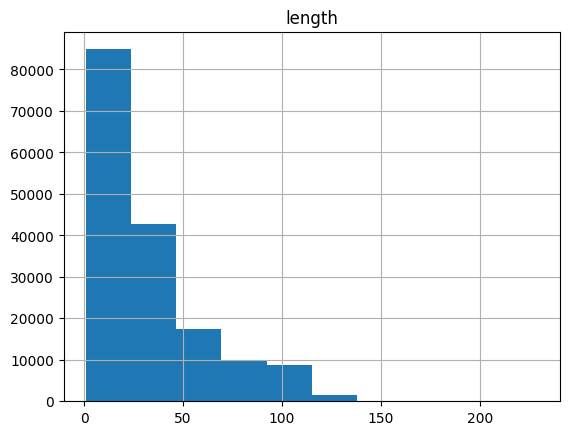

In [32]:
# 분포 시각화 : DataFrame의 Histogram 시각화 (df.hist())
len_df.hist()

In [33]:
#단어 길이 통계 정보 확인 (df.describe())
len_df.describe()

,length
count,165384.000000
mean,33.234309
std,27.345562
min,1.000000
25%,14.000000
50%,23.000000
75%,43.000000
max,229.000000


In [38]:
#텍스트의 길이가 설정한 max_len 이하인 비율 계산
#def below_threshold_len(max_len, texts):
    #count = 0
    #for text in texts:
        #if len(text.split()) <= max_len:
            #count += 1
    #return(f'길이가 {max_len} 이하인 샘플의 비율: {count/len(texts)*100:.4f}%')

from mylib.my_utils import below_threshold_len

max_len = 60
below_threshold_len(max_len, texts)

'길이가 60 이하인 샘플의 비율: 99.9988%'